In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [2]:
wide_df = pd.read_csv("../../events/gw/gw_params_wide.dat", sep=" ")
detection_df = pd.read_csv("../../events/detection/detection_output/wide_ETL_CE.dat", sep=" ")
kn_params = pd.read_csv("../../events/kilonova/kn_params_wide.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(wide_df["prompt_collapse"]==1)/wide_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 73/238, 0.307,  0.7548668655397194


In [5]:
73 / np.sum(wide_df["prompt_collapse"]==1)  * 1e4

np.float64(10.684542540579306)

In [7]:
(238-73) / np.sum(wide_df["prompt_collapse"]>=1) * 1e4

np.float64(18.230029830957907)

In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -2.04594800736782
zeta quantile:  0.14797141266443598


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  27.112 331.402


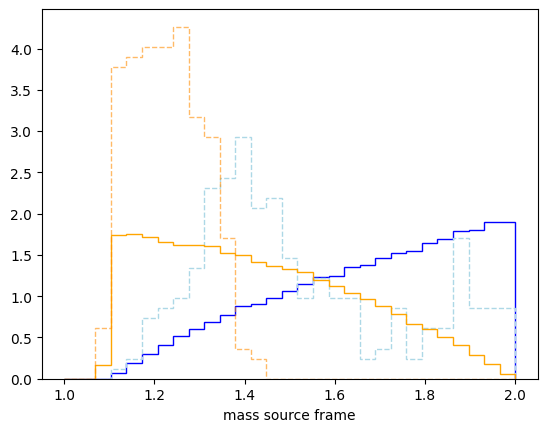

In [6]:
bins = np.linspace(1, 2, 30)

plt.hist(wide_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(wide_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

(array([3.97571795e-05, 4.50581368e-04, 4.17450385e-03, 7.04099649e-02,
        1.53900042e-01, 1.72069073e-01, 1.69021023e-01, 1.38527266e-01,
        2.19949970e-01, 2.70931926e-01]),
 array([-8.88853262, -8.05483392, -7.22113522, -6.38743653, -5.55373783,
        -4.72003913, -3.88634044, -3.05264174, -2.21894304, -1.38524434,
        -0.55154565]),
 [<matplotlib.patches.Polygon at 0x7efbe33a3710>])

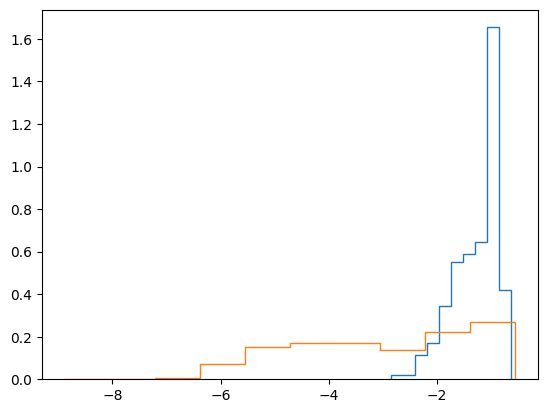

In [7]:
plt.hist(log10_mej_wind, histtype="step", density=True)
plt.hist(kn_params["log10_mej_wind"], histtype="step", density=True)

(array([0.67812914, 0.76723154, 0.8146002 , 0.86901254, 0.91902258,
        0.99562247, 1.03682793, 0.85263601, 0.67055719, 0.40113689,
        0.120975  , 0.02852686, 0.03275306, 0.04613603, 0.05828635,
        0.07976954, 0.11287478, 0.16482183, 0.23842816, 0.40976539,
        0.88873481, 0.52686637, 0.38035807, 0.2884382 , 0.22310818,
        0.16041954, 0.07571943, 0.01109378, 0.        , 0.        ,
        0.        , 0.        ]),
 array([-4.      , -3.915625, -3.83125 , -3.746875, -3.6625  , -3.578125,
        -3.49375 , -3.409375, -3.325   , -3.240625, -3.15625 , -3.071875,
        -2.9875  , -2.903125, -2.81875 , -2.734375, -2.65    , -2.565625,
        -2.48125 , -2.396875, -2.3125  , -2.228125, -2.14375 , -2.059375,
        -1.975   , -1.890625, -1.80625 , -1.721875, -1.6375  , -1.553125,
        -1.46875 , -1.384375, -1.3     ]),
 [<matplotlib.patches.Polygon at 0x7efbe332eed0>])

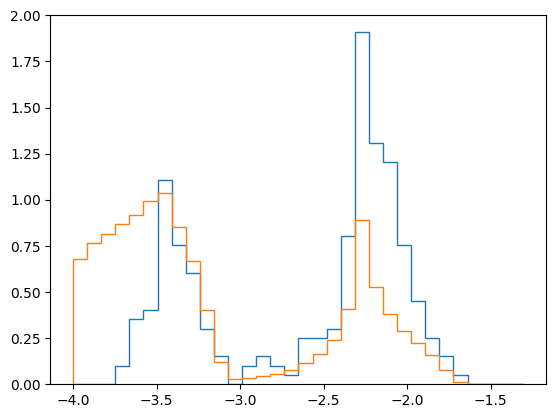

In [8]:
bins= np.linspace(-4, -1.3, 33)

plt.hist(events["log10_mej_dyn"], histtype="step", density=True, bins=bins)
plt.hist(kn_params["log10_mej_dyn"], histtype="step", density=True, bins=bins)

(array([0.19021207, 0.57334299, 0.94490862, 1.38955703, 1.83642006,
        2.32560713, 2.8868927 , 3.43981188, 4.06384528, 4.62119373]),
 array([0.55100099, 0.59590083, 0.64080068, 0.68570052, 0.73060037,
        0.77550022, 0.82040006, 0.86529991, 0.91019975, 0.9550996 ,
        0.99999944]),
 [<matplotlib.patches.Polygon at 0x7f63a6c7bd10>])

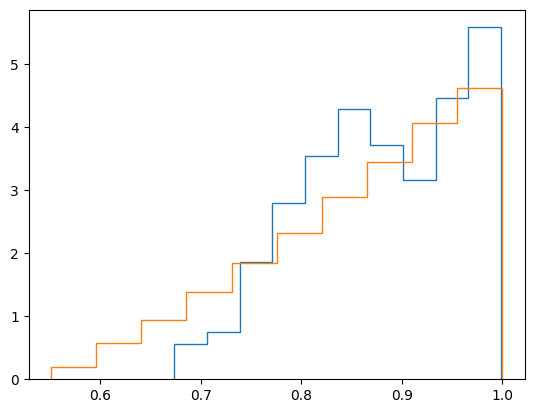

In [10]:
mask = events["prompt_collapse"] >1

plt.hist(events.loc[mask, "mass_2_source"] / events.loc[mask, "mass_1_source"], density=True, histtype="step")
plt.hist(wide_df["mass_2"] / wide_df["mass_1"], density=True, histtype="step")

(array([0.15215221, 0.3947467 , 0.57489295, 0.72710669, 0.87156823,
        0.89193312, 0.77128189, 0.62220595, 0.41129702, 0.15147543]),
 array([2.20148046, 2.38105686, 2.56063327, 2.74020968, 2.91978609,
        3.0993625 , 3.27893891, 3.45851532, 3.63809173, 3.81766814,
        3.99724455]),
 [<matplotlib.patches.Polygon at 0x7efc9305d690>])

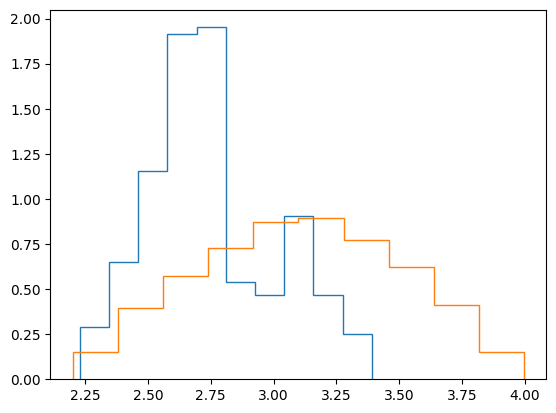

In [10]:
plt.hist(events["mass_2_source"] + events["mass_1_source"], density=True, histtype="step")
plt.hist(wide_df["mass_2_source"] + wide_df["mass_1_source"], density=True, histtype="step")

(array([0.01436047, 0.01215117, 0.0037282 , 0.00138081, 0.00082849,
        0.        , 0.        , 0.00013808, 0.        , 0.00027616]),
 array([ 27.112,  57.541,  87.97 , 118.399, 148.828, 179.257, 209.686,
        240.115, 270.544, 300.973, 331.402]),
 [<matplotlib.patches.Polygon at 0x7efbe3bbfc10>])

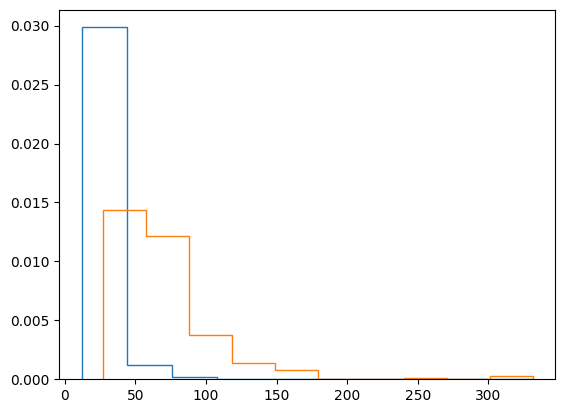

In [16]:
plt.hist(detection_df.loc[detection_df["gw_detected"].astype(bool), "snr"], histtype="step", density=True)
plt.hist(events['snr'], histtype="step", density=True)

In [17]:
events["snr"].min()

np.float64(27.112)